# Eksperimen TCN untuk Prediksi Gempa Triwulan
Notebook ini menganalisis hasil sebelumnya lalu melatih model TCN (Temporal Convolutional Network)
untuk dibandingkan dengan baseline seasonal naive pada target jumlah gempa M>=5.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Konfigurasi eksperimen
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

MAG_THRESHOLD = 5.0
TARGET_COL = 'count_m5'
TEST_QUARTERS = 8
LOOKBACK = 8
HORIZON = 1
SEASON_LENGTH = 4
EPOCHS = 300
BATCH_SIZE = 8

def find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'data_gempa_kaggle' / 'katalog_gempa_v2.tsv').exists():
            return p
    raise FileNotFoundError('Project root tidak ditemukan dari current working directory.')

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / 'data_gempa_kaggle' / 'katalog_gempa_v2.tsv'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'model_tcn_experiment'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT_ROOT)
print('Artifact dir :', ARTIFACT_DIR)

Project root : d:\Projects\bencana_dicoding_app\timeseries_triwulan\notebooks
Artifact dir : d:\Projects\bencana_dicoding_app\timeseries_triwulan\notebooks\timeseries_triwulan\artifacts\model_tcn_experiment


In [ ]:
# Analisis hasil model sebelumnya (jika artifacts tersedia)
prev_metrics = []

m_a = PROJECT_ROOT / 'artifacts' / 'model_a_h1' / 'metadata.json'
if m_a.exists():
    data = json.loads(m_a.read_text(encoding='utf-8'))
    prev_metrics.append({
        'model': 'SeasonalNaive_H1',
        'MAE': data['metrics']['mae'],
        'RMSE': data['metrics']['rmse'],
        'sMAPE(%)': data['metrics']['smape_percent']
    })

candidates = [
    PROJECT_ROOT / 'artifacts' / 'model_compare_sarima_sgboost' / 'metrics_comparison.csv'
]
for fp in candidates:
    if fp.exists():
        cmp_df = pd.read_csv(fp)
        prev_metrics.extend(cmp_df.to_dict(orient='records'))
        break

prev_df = pd.DataFrame(prev_metrics)
if prev_df.empty:
    print('Belum ada metrics model sebelumnya yang ditemukan.')
else:
    print('Ringkasan hasil model sebelumnya:')
    display(prev_df.sort_values('RMSE'))

Ringkasan hasil model sebelumnya:


,model,MAE,RMSE,sMAPE(%)
0,SeasonalNaive_H1,20.875000,23.094913,52.287813
1,SARIMA,27.461885,30.707384,63.610183
2,SGBoost,32.532542,35.459390,70.413722


In [4]:
# Load data dan agregasi triwulan
df = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
df = df.dropna(subset=['datetime', 'magnitude']).copy()
df['datetime'] = df['datetime'].dt.tz_convert(None)

q_all = df.resample('QE', on='datetime').size().rename('count_all')
q_m5 = (df[df['magnitude'] >= MAG_THRESHOLD]
        .resample('QE', on='datetime').size().rename('count_m5'))
quarterly = pd.concat([q_all, q_m5], axis=1).fillna(0.0)
quarterly.index.name = 'quarter_end'

last_ts = df['datetime'].max()
last_q_end = last_ts.to_period('Q').end_time
dropped_partial_quarter = False
if last_ts < last_q_end and len(quarterly) > 0:
    quarterly = quarterly.iloc[:-1].copy()
    dropped_partial_quarter = True

quarterly['quarter'] = quarterly.index.to_period('Q').astype(str)
quarterly = quarterly.reset_index(drop=False)

print('Total triwulan:', len(quarterly))
print('Drop triwulan parsial terakhir:', dropped_partial_quarter)
quarterly.tail()

Total triwulan: 68
Drop triwulan parsial terakhir: True


,quarter_end,count_all,count_m5,quarter
63,2024-09-30,1571,39.0,2024Q3
64,2024-12-31,1655,25.0,2024Q4
65,2025-03-31,3876,27.0,2025Q1
66,2025-06-30,4820,13.0,2025Q2
67,2025-09-30,5084,25.0,2025Q3


In [5]:
# Split train-test
n = len(quarterly)
train_end = n - TEST_QUARTERS
if train_end <= LOOKBACK + 4:
    raise ValueError('Data train terlalu pendek untuk LOOKBACK saat ini.')

train_df = quarterly.iloc[:train_end].copy()
test_df = quarterly.iloc[train_end:].copy()

train_df.to_csv(ARTIFACT_DIR / 'train_split.csv', index=False)
test_df.to_csv(ARTIFACT_DIR / 'test_split.csv', index=False)

print('Train rows:', len(train_df), '| Test rows:', len(test_df))
print('Train range:', train_df['quarter'].iloc[0], '->', train_df['quarter'].iloc[-1])
print('Test range :', test_df['quarter'].iloc[0], '->', test_df['quarter'].iloc[-1])

Train rows: 60 | Test rows: 8
Train range: 2008Q4 -> 2023Q3
Test range : 2023Q4 -> 2025Q3


In [6]:
# Helper metrics
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.abs(y_true) + np.abs(y_pred)
    mask = den != 0
    if not np.any(mask):
        return np.nan
    return np.mean(2.0 * np.abs(y_true[mask] - y_pred[mask]) / den[mask]) * 100.0

def evaluate(name, y_true, y_pred):
    return {
        'model': name,
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'sMAPE(%)': float(smape(y_true, y_pred)),
    }

In [7]:
# Persiapan data sequence untuk TCN
series = quarterly[TARGET_COL].astype(float).reset_index(drop=True)

mean_train = float(series.iloc[:train_end].mean())
std_train = float(series.iloc[:train_end].std(ddof=0))
std_train = std_train if std_train > 1e-8 else 1.0

scaled = (series - mean_train) / std_train

X_seq, y_seq = [], []
for i in range(LOOKBACK, train_end):
    X_seq.append(scaled.iloc[i - LOOKBACK:i].values)
    y_seq.append(scaled.iloc[i])

X_seq = np.asarray(X_seq, dtype=np.float32)[..., np.newaxis]
y_seq = np.asarray(y_seq, dtype=np.float32)

# validation dari bagian akhir train
val_size = max(4, int(0.2 * len(X_seq)))
X_train_tcn, X_val_tcn = X_seq[:-val_size], X_seq[-val_size:]
y_train_tcn, y_val_tcn = y_seq[:-val_size], y_seq[-val_size:]

print('X_train_tcn:', X_train_tcn.shape, '| X_val_tcn:', X_val_tcn.shape)

X_train_tcn: (42, 8, 1) | X_val_tcn: (10, 8, 1)


In [8]:
# Definisi dan training model TCN ringan
inp = layers.Input(shape=(LOOKBACK, 1))
x = inp

for d in [1, 2, 4]:
    x_in = x
    x = layers.Conv1D(32, kernel_size=3, padding='causal', dilation_rate=d, activation='relu')(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Conv1D(32, kernel_size=3, padding='causal', dilation_rate=d, activation='relu')(x)
    if x_in.shape[-1] != x.shape[-1]:
        x_in = layers.Conv1D(32, kernel_size=1, padding='same')(x_in)
    x = layers.Add()([x, x_in])

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(1)(x)

tcn_model = models.Model(inp, out)
tcn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)
]

history = tcn_model.fit(
    X_train_tcn, y_train_tcn,
    validation_data=(X_val_tcn, y_val_tcn),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
    callbacks=cb
)

print('Best val_loss:', float(np.min(history.history['val_loss'])))




Best val_loss: 1.8576828241348267


In [10]:
# Forecast recursive untuk test window
hist_scaled = scaled.iloc[:train_end].tolist()
tcn_preds = []

for _ in range(TEST_QUARTERS):
    x_in = np.asarray(hist_scaled[-LOOKBACK:], dtype=np.float32).reshape(1, LOOKBACK, 1)
    yhat_scaled = float(tcn_model.predict(x_in, verbose=0)[0, 0])
    yhat = max(0.0, yhat_scaled * std_train + mean_train)
    tcn_preds.append(yhat)
    hist_scaled.append(yhat_scaled)

# Baseline seasonal naive untuk pembanding langsung
seasonal_naive_preds = []
hist_actual = series.iloc[:train_end].tolist()
for i in range(TEST_QUARTERS):
    idx_global = train_end + i
    seasonal_idx = idx_global - SEASON_LENGTH
    pred = float(series.iloc[seasonal_idx])
    seasonal_naive_preds.append(max(0.0, pred))

y_true = series.iloc[train_end:train_end + TEST_QUARTERS].values

metrics_tcn = evaluate('TCN', y_true, tcn_preds)
metrics_naive = evaluate('SeasonalNaive_H1', y_true, seasonal_naive_preds)
metrics_df = pd.DataFrame([metrics_tcn, metrics_naive]).sort_values('RMSE')
display(metrics_df)

,model,MAE,RMSE,sMAPE(%)
1,SeasonalNaive_H1,20.87500,23.094913,52.287813
0,TCN,32.36002,35.722869,69.986169


In [12]:
# Simpan artifacts
pred_df = pd.DataFrame({
    'quarter': test_df['quarter'].values,
    'actual': y_true,
    'tcn_pred': tcn_preds,
    'seasonal_naive_pred': seasonal_naive_preds
})
pred_df['tcn_abs_error'] = np.abs(pred_df['actual'] - pred_df['tcn_pred'])
pred_df['naive_abs_error'] = np.abs(pred_df['actual'] - pred_df['seasonal_naive_pred'])

pred_df.to_csv(ARTIFACT_DIR / 'predictions_test.csv', index=False)
metrics_df.to_csv(ARTIFACT_DIR / 'metrics_tcn_vs_naive.csv', index=False)
pd.DataFrame(history.history).to_csv(ARTIFACT_DIR / 'training_history.csv', index=False)
tcn_model.save(ARTIFACT_DIR / 'tcn_model.keras')

metadata = {
    'dataset_path': str(DATA_PATH),
    'target_col': TARGET_COL,
    'mag_threshold': MAG_THRESHOLD,
    'total_quarters': int(n),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'dropped_partial_last_quarter': bool(dropped_partial_quarter),
    'lookback': int(LOOKBACK),
    'epochs': int(EPOCHS),
    'batch_size': int(BATCH_SIZE),
    'scaler': {'mean_train': mean_train, 'std_train': std_train},
    'metrics': metrics_df.to_dict(orient='records')
}
with open(ARTIFACT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved artifacts:')
for p in sorted(ARTIFACT_DIR.glob('*')):
    print('-', p.name)

Saved artifacts:
- metadata.json
- metrics_tcn_vs_naive.csv
- predictions_test.csv
- tcn_model.keras
- test_split.csv
- train_split.csv
- training_history.csv


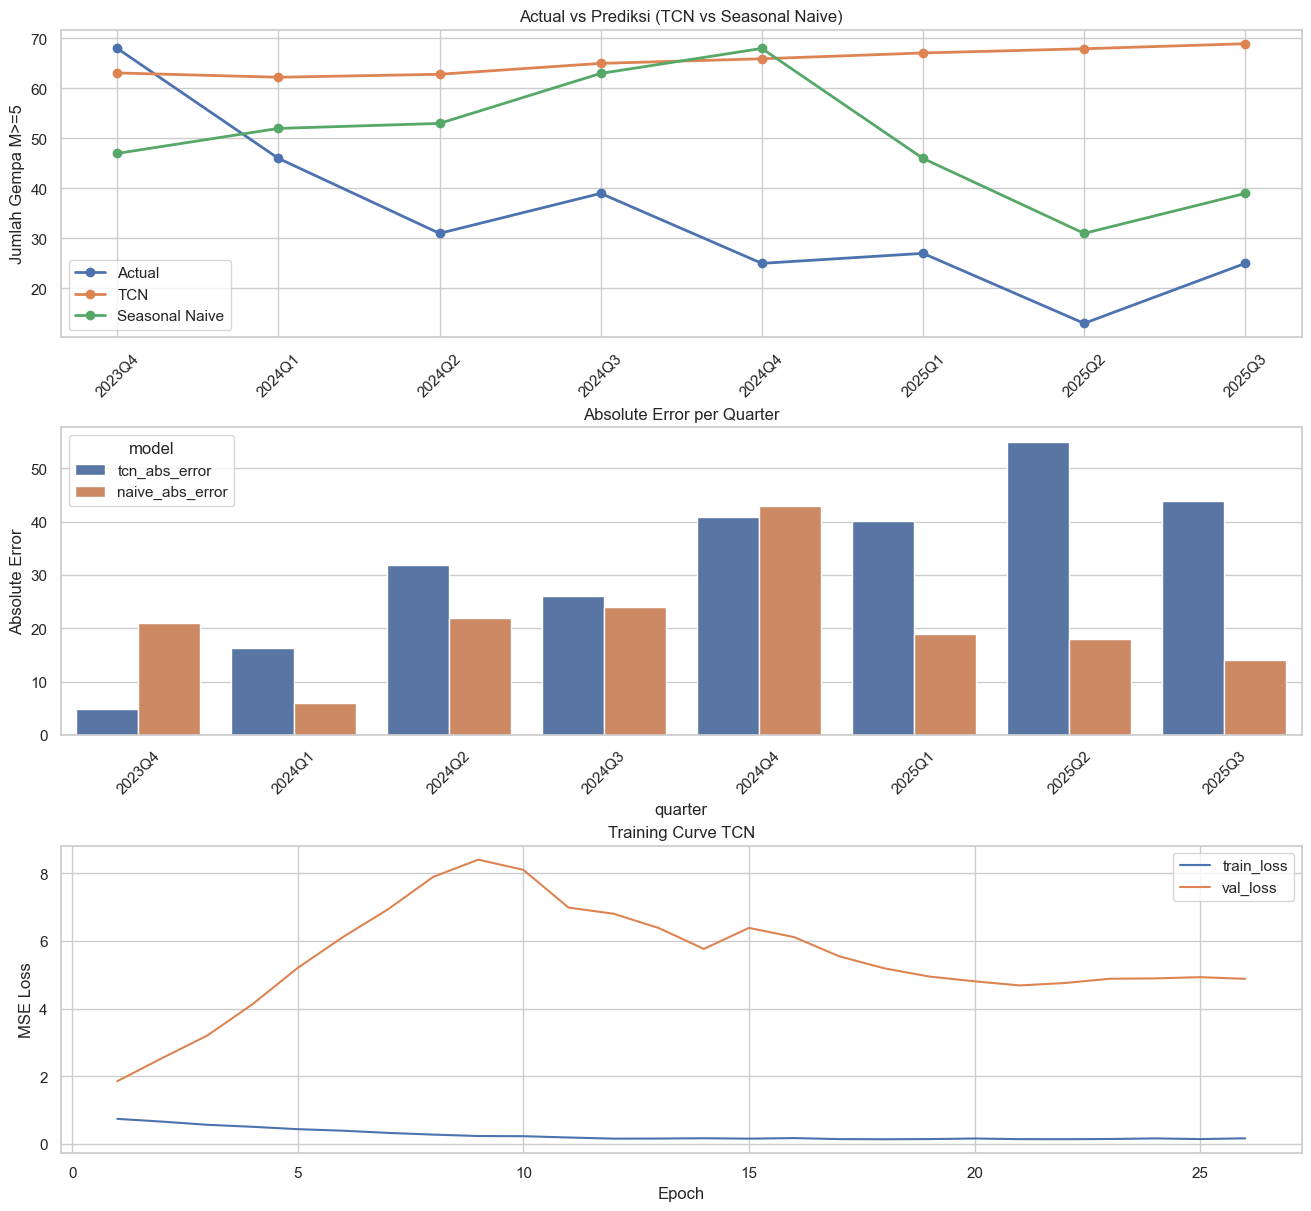

In [13]:
# Visualisasi hasil
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(13, 12), constrained_layout=True)

axes[0].plot(pred_df['quarter'], pred_df['actual'], marker='o', linewidth=2, label='Actual')
axes[0].plot(pred_df['quarter'], pred_df['tcn_pred'], marker='o', linewidth=2, label='TCN')
axes[0].plot(pred_df['quarter'], pred_df['seasonal_naive_pred'], marker='o', linewidth=2, label='Seasonal Naive')
axes[0].set_title('Actual vs Prediksi (TCN vs Seasonal Naive)')
axes[0].set_ylabel('Jumlah Gempa M>=5')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

err_plot = pred_df.melt(
    id_vars=['quarter'],
    value_vars=['tcn_abs_error', 'naive_abs_error'],
    var_name='model',
    value_name='abs_error'
)
sns.barplot(data=err_plot, x='quarter', y='abs_error', hue='model', ax=axes[1])
axes[1].set_title('Absolute Error per Quarter')
axes[1].set_ylabel('Absolute Error')
axes[1].tick_params(axis='x', rotation=45)

hist_df = pd.DataFrame(history.history)
axes[2].plot(hist_df.index + 1, hist_df['loss'], label='train_loss')
axes[2].plot(hist_df.index + 1, hist_df['val_loss'], label='val_loss')
axes[2].set_title('Training Curve TCN')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].legend()

plt.savefig(ARTIFACT_DIR / 'tcn_comparison_plot.png', dpi=160, bbox_inches='tight')
plt.show()